<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_3-WorkGroupModelsKind/blob/main/Week03/src/KM_CP_W3_E3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Trabajo 3: Movilizacion Automatica - Aprendizaje Autonomo


# 📋 Información del Proyecto
- Autores:
  - CARRERA DIAZ CHRISTIAN JAVIER
  - CALVACHI MORENO DANILO JAVIER
  - PILATASIG CHANATASIG EDISON MAURICIO
- Versión: 1.0.0
- Licencia: MIT


### **🎯 Introducción:**

Una empresa de movilidad desea desarrollar un agente capaz de desplazarse de manera autónoma por una pequeña representación de una ciudad. El agente debe encontrar una ruta desde un punto de partida hasta un destino, evitando obstáculos y tomando decisiones que minimicen el costo de su recorrido.


### **🌍 Contexto del trabajo**

Para ello, se utilizará una cuadrícula que representa la ciudad, en la que existirán calles transitables, obstáculos e intersecciones controladas por semáforos. El agente podrá desplazarse en las cuatro direcciones y, cuando sea necesario, podrá decidir esperar ante un semáforo en rojo.

### **✅ Objetivo General**

El objetivo será desarrollar un agente mediante Aprendizaje por Refuerzo, utilizando Q-Learning, que aprenda una política capaz de maximizar la recompensa acumulada y encontrar rutas eficientes hacia el destino.
Durante el ejercicio se deberán analizar diferentes configuraciones del entorno y estudiar cómo factores como la función de recompensa, la exploración y los estados de los semáforos afectan el comportamiento aprendido por el agente.

# 🏗️ Preparación de datos

*******************************************************************************

## 🔍 Creación del Mapa De Representación De Ciudad

En este punto crearemos una matriz que simule una ciudad de 8x8

- S → punto de partida
- T → destino
- . → calle transitable
- ´#´ → semáforo

In [40]:
# Importamos librerias

import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Creamos el mapa de la ciudad que simule una ciudad

city_route = [
    ["S", ".", ".", "L", ".", ".", ".", "."],
    [".", "#", ".", "L", ".", "#", "#", "."],
    [".", "#", ".", ".", ".", ".", ".", "."],
    [".", ".", "#", "#", "#", "L", "#", "."],
    ["#", ".", ".", ".", ".", ".", "#", "."],
    [".", "#", "#", "#", ".", ".", "L", "."],
    [".", ".", ".", "#", ".", "#", "#", "."],
    [".", ".", ".", ".", ".", ".", "T", "."],
]

# Definimos el tamaño de filas y columnas
ROWS = len(city_route)
COLS = len(city_route[0])

# Posición inicial y destino
start_position = (0, 0)
target_position = (7, 5)

# Imprimimos la routa de la ciudad
for row in city_route:
    print(" ".join(row))

S . . L . . . .
. # . L . # # .
. # . . . . . .
. . # # # L # .
# . . . . . # .
. # # # . . L .
. . . # . # # .
. . . . . . T .


# 🚀 Implementación del Agente

## 🚀 Acciones de las agente

In [41]:
# ============================================================
# 2. ACCIONES
# ============================================================

# Le damos valor a las acciones
UP = 0
DOWN = 1
LEFT = 2
RIGHT = 3
WAIT = 4

actions = {
    UP: "UP",
    DOWN: "DOWN",
    LEFT: "LEFT",
    RIGHT: "RIGHT",
    WAIT: "WAIT"
}

# Colocamos el numero de acciones
NUM_ACTIONS = len(actions)

# Cambios de posición para cada movimiento
movement = {
    UP: (-1, 0),
    DOWN: (1, 0),
    LEFT: (0, -1),
    RIGHT: (0, 1)
}

## 🚀Semáforos

In [42]:
# ============================================================
# 3. SEMÁFOROS
# ============================================================

# Cada semáforo tiene un estado:
# 0 = rojo
# 1 = verde

traffic_lights = {
    (0, 3): "red",
    (1, 3): "red",
    (3, 5): "green",
    (5, 6): "red",
}

NUM_LIGHTS = len(traffic_lights)

# Guardamos las posiciones de los semáforos
light_positions = list(traffic_lights.keys())

## 🚀Estados del agente

In [43]:
import numpy as np

# ============================================================
# 4. ESTADO
# ============================================================

"""
Nuestro estado contiene:
  posición del agente
  estado de lis 4 semáforos

Ejemplo:

(row, col, light1, light2, light3, light4)

Por ejemplo:

(0, 2, 0, 1, 1, 0)

significa:

Agente está en (0,2)

Semáforo 1 = rojo
Semáforo 2 = verde
Semáforo 3 = verde
Semáforo 4 = rojo
"""

def get_state(position, lights):
  """
  Convierte la posición + semáforos en un estado
  """
  state = [position[0], position[1]]

  for light_position in light_positions:
    state.append(lights[light_position])

  return tuple(state)

# ============================================================
# 5. CREAR TODOS LOS ESTADOS POSIBLES
# ============================================================

"""
El agente puede estar en cualquier celda transitable.

Además cada semáforo puede estar:

0 = rojo
1 = verde


Con 4 semáforos tenemos:

2^4 = 16 combinaciones de semáforos

"""

valid_positions = []

for row in range(ROWS):
  for col in range(COLS):
    # No consideramos obstáculos como posiciones válidas
    if city_route[row][col] != "#": # <-- FIX: Changed from '==' to '!='
      valid_positions.append((row, col))

# Creamos todas las combinaciones posiblems de semáforos

all_states = []

for position in valid_positions:
  for light1 in [0,1]:
    for light2 in [0,1]:
      for light3 in [0,1]:
        for light4 in [0,1]:
            state = (position[0], position[1], light1, light2, light3, light4)
            all_states.append(state)

# Diccionario para convertir estado -> número
state_to_id = {
    state : i
    for i, state in enumerate(all_states)
}

id_to_state = {
    i : state
    for i, state in enumerate(all_states)
}

NUM_STATES = len(all_states)

print("Número de estados posibles: ", NUM_STATES)
print("Número de acciones: ", NUM_ACTIONS)


Número de estados posibles:  768
Número de acciones:  5


## 🚀 Tabla Q

In [44]:
"""
Q[state, action]

Por ejemplo:

Q[25, RIGHT]

representa:

¿ Cúanto valor tiene la acción RIGHT en el estado 25 ?
"""

Q = np.zeros((NUM_STATES, NUM_ACTIONS))

print("Dimensiones de Q: ", Q.shape)

Dimensiones de Q:  (768, 5)


## 🚀 Entorno

In [45]:
# ============================================================
# 7. ENTORNO
# ============================================================

# Creamos una clase de entorno con todos los metodos necesarios

class CityEnvironment:
  def __init__(self, rewards):
    # Guardamos las recompensans en la clase
    self.rewards = rewards
    self.reset()

  def reset(self):
    # Volvemos al inicio
    self.position = start_position

    # Reiniciamos semáforos
    self.traffic_lights = {
        (0, 3): 0,
        (1, 3): 0,
        (3, 5): 1,
        (5, 6): 0,
    }

    # Número de pasos
    self.steps = 0

    return get_state(self.position, self.traffic_lights)

  def step(self, action):
    # Actualizamos el número de pasos
    self.steps += 1

    current_position = self.position

    # ====================================================
    # CASO 1: WAIT
    # ====================================================

    if action == WAIT:
      reward = self.rewards["wait"]

      # Esperar cambiar los semáforos
      self.update_traffic_lights()
      next_position = current_position

    # ====================================================
    # CASO 2: MOVIMIENTO
    # ====================================================

    else:
      # Actualizamos la posición
      row, col = current_position
      drow, dcol = movement[action]

      new_row = row + drow
      new_col = col + dcol

      next_position = (new_row, new_col)

      # ================================================
      # ¿SALIMOS DEL MAPA?
      # ================================================

      if (
          new_row < 0
          or new_row >= ROWS
          or new_col < 0
          or new_col >= COLS
      ):
        reward = self.rewards["obstacle"]
        next_position = current_position

      # ================================================
      # ¿CHOCA CON OBSTÁCULO?
      # ================================================
      elif city_route[new_row][new_col] == "#":

        reward = self.rewards["obstacle"]
        next_position = current_position

      # ================================================
      # ¿ES UN SEMÁFORO?
      # ================================================

      elif next_position in traffic_lights:

        light_state = self.traffic_lights[next_position]

        # Rojo
        if light_state == 0:
          reward = self.rewards["red_light"]
          # No puede avanzar
          next_position = current_position

        # Verde
        else:
          reward = self.rewards["move"]
          self.position = next_position
      # ================================================
      # CELDA NORMAL
      # ================================================

      else:
          reward = self.rewards["move"]
          self.position = next_position

    # Actualizamos posición
    self.position = next_position

    # ====================================================
    # ¿LLEGÓ AL DESTINO?
    # ====================================================

    done = False

    if self.position == target_position:
      reward = self.rewards["destination"]
      done = True

    # ====================================================
    # LIMITE DE PASOS
    # ====================================================

    if self.steps >= 200:
      done = True

    # Cambiamos semáforos después del movimiento

    if action != WAIT:
      self.update_traffic_lights()

    # ====================================================
    # CONSTRUIR SIGUIENTE ESTADO
    # ====================================================

    next_state = get_state(
        self.position,
        self.traffic_lights
    )

    return next_state, reward, done

  # ========================================================
  # CAMBIO DE SEMÁFOROS
  # ========================================================

  def update_traffic_lights(self):
    """
    Para simplificar:

    Cada vez que pasa un paso, los semaforos cambian de estado

    rojo -> verde
    verde -> rojo
    """

    for position in self.traffic_lights:
        # Corrected line: Access self.traffic_lights (the dictionary), not the method itself
        current = self.traffic_lights[position]
        self.traffic_lights[position] = 1 - current


## 🚀 Política e-Greedy



In [46]:
# ============================================================
# 8. POLÍTICA ε-GREEDY
# ============================================================

def choosen_action(state_id, epsilon):
  """
    ε-greedy:
    Con probabilidad epsilon:
      exploramos -> acción aleatoria
    Con probabilidad 1-epsilon
      exploramos -> mejor acción conocida
  """

  if random.random() < epsilon:
    # Exploracion
    action = random.randint(0, NUM_ACTIONS - 1)
  else:
    # Exploracion
    action = np.argmax(Q[state_id])

  return action


## 🚀 Parámetos de Q-Learning

In [47]:
alpha = 0.1   # tasa de aprendizaje
gamma = 0.95  # factor de descuento

epsilon = 0.1 # empezamos explorando mucho
epsilon_min = 0.05
epsilon_decay = 0.995

episodes = 5000

# Lista de rewards
rewards = {
    "move": -1,
    "wait": -2,
    "obstacle": -10,
    "red_light": -10,
    "destination": 100
}

## 🚀 Entrenamiento

In [56]:
# Metodo de entrenamiento

def train_agent(episodes, env, epsilon):
  environment = env
  rewards_per_episode = []
  steps_per_episode = []

  for episode in range(episodes):
    # -----------------------------------------
    # Reiniciar entorno
    # ------------------------------------------

    state = environment.reset()
    state_id = state_to_id[state]

    done = False
    total_reward = 0
    step = 0 # Initialized 'step' here

    # -----------------------------------------
    # Ejecutar Episodio
    # ------------------------------------------

    while not done:
      # -----------------------------------------
      # Elegir acción
      # ------------------------------------------

      action = choosen_action(state_id, epsilon)

      # Ejecutar acción
      next_state, reward, done = environment.step(action)

      next_state_id = state_to_id[next_state]

      # -----------------------------------------
      # Ecuación de Q-Learning
      # ------------------------------------------

      old_value = Q[state_id, action]
      best_next_value = np.max(Q[next_state_id])

      new_value = old_value + alpha * (reward + gamma * best_next_value - old_value)

      Q[state_id, action] = new_value

      # Pasamos al siguiente estado
      state_id = next_state_id
      total_reward += reward
      step += 1 # Corrected from 'steps += 1' to 'step += 1'

    # -----------------------------------------
    # Reducir exploración
    # ------------------------------------------

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


    rewards_per_episode.append(total_reward)
    steps_per_episode.append(step)

    # Monstrar progreso

    if(episode + 1) % 500 == 0:

        print(
            f"Episodio {episode + 1} | "
            f"Reward: {total_reward:.0f} | "
            f"Steps: {step} | "
            f"Epsilon: {epsilon:.3f}"
        )

  # ============================================================
  # 11. RESULTADOS DEL ENTRENAMIENTO
  # ============================================================

  print("\nEntrenamiento terminado.")

  print("Epsilon final:", epsilon)

  print("Mejor reward:",
        max(rewards_per_episode))
  # ============================================================
  # 12. GRAFICAR RECOMPENSA
  # ============================================================

  plt.figure(figsize=(10, 5))

  plt.plot(rewards_per_episode)

  plt.xlabel("Episodio")
  plt.ylabel("Reward acumulado")

  plt.title("Evolución del Reward durante Q-Learning")

  plt.grid()

  plt.show()

Episodio 500 | Reward: 87 | Steps: 13 | Epsilon: 0.050
Episodio 1000 | Reward: 87 | Steps: 13 | Epsilon: 0.050
Episodio 1500 | Reward: 87 | Steps: 13 | Epsilon: 0.050
Episodio 2000 | Reward: 87 | Steps: 13 | Epsilon: 0.050
Episodio 2500 | Reward: 87 | Steps: 13 | Epsilon: 0.050
Episodio 3000 | Reward: 87 | Steps: 13 | Epsilon: 0.050
Episodio 3500 | Reward: 87 | Steps: 13 | Epsilon: 0.050
Episodio 4000 | Reward: 87 | Steps: 13 | Epsilon: 0.050
Episodio 4500 | Reward: 79 | Steps: 13 | Epsilon: 0.050
Episodio 5000 | Reward: 89 | Steps: 12 | Epsilon: 0.050

Entrenamiento terminado.
Epsilon final: 0.05
Mejor reward: 89


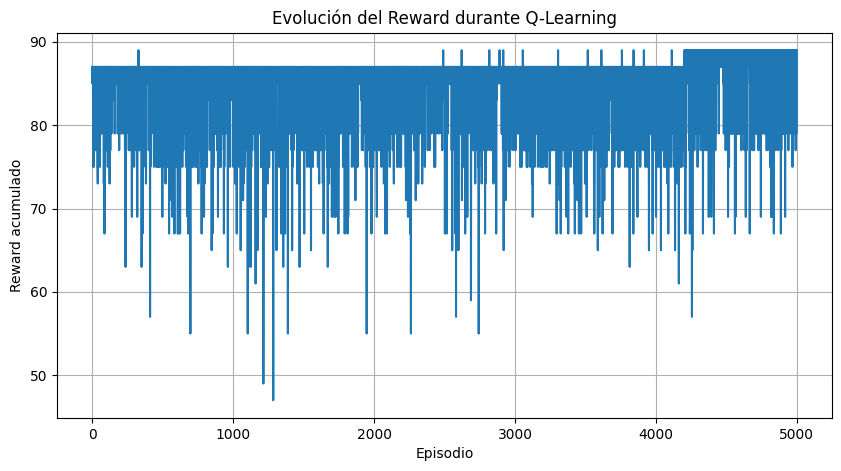

In [57]:
environment = CityEnvironment(rewards)

# Entrenar el módelo
train_agent(episodes, environment, epsilon)

# 🚀 Prueba del Agente Entrenado

In [64]:
def test_agent(episodes, environment):
  state = environment.reset()

  state_id = state_to_id[state]

  done = False

  path = [environment.position]

  total_reward = 0

  while not done:

      # Ahora NO exploramos.
      # Siempre elegimos la mejor acción.

      action = np.argmax(Q[state_id])


      next_state, reward, done = environment.step(action)

      next_state_id = state_to_id[next_state]


      path.append(environment.position)

      total_reward += reward

      state_id = next_state_id


  print("\n===================================")
  print("RESULTADO DEL AGENTE")
  print("===================================")

  print("Ruta encontrada:")

  for position in path:

      print(position)

  print("\nReward total:", total_reward)

  print("Número de pasos:", len(path) - 1)

  return path

In [65]:
# Prueba del Agente
path = test_agent(episodes, environment)


RESULTADO DEL AGENTE
Ruta encontrada:
(0, 0)
(1, 0)
(2, 0)
(3, 0)
(3, 1)
(4, 1)
(4, 2)
(4, 3)
(4, 4)
(5, 4)
(6, 4)
(7, 4)
(7, 5)

Reward total: 67
Número de pasos: 12


##  📈 Ruta A Seguir Sobre El Mapa

In [67]:
def graph_path(path):
  display_map = [row.copy() for row in city_route]

  for i, position in enumerate(path):

      row, col = position

      if display_map[row][col] not in ["S", "T", "L"]:

          display_map[row][col] = "*"


  print("\nMAPA + RUTA")
  print("===================================")

  for row in display_map:

      print(" ".join(row))

In [68]:
# Graficamos el camino realizado por el agente

graph_path(path)


MAPA + RUTA
S . . L . . . .
* # . L . # # .
* # . . . . . .
* * # # # L # .
# * * * * . # .
. # # # * . L .
. . . # * # # .
. . . . * * T .


### 🧠 Interpretación

El agente encontró una ruta válida desde S hasta T, evitando los obstáculos (#) y aprendiendo a desplazarse principalmente por las celdas transitables (*). Se observa que la trayectoria no es necesariamente la más corta, ya que el agente debe considerar también los estados de los semáforos y el costo de las acciones; por ello, puede realizar movimientos adicionales para alcanzar el destino. En términos de Q-Learning, esto indica que la tabla Q logró aprender una política que prioriza alcanzar el destino (+100) mientras evita obstáculos y situaciones penalizadas, aunque la eficiencia de la ruta todavía puede mejorarse mediante más entrenamiento o ajustando la función de recompensa.


##  📈 Experimento 1: Penalizar más cada movimiento

En este primer experimento vamos a cambiar la lista de recompensas con el objetivo de si cada movimiento cuesta más, el agente tendrá mayor incentivo para encontrar rutas más cortas y evitar movimientos innecesarios.

Episodio 500 | Reward: 67 | Steps: 12 | Epsilon: 0.050
Episodio 1000 | Reward: 67 | Steps: 12 | Epsilon: 0.050
Episodio 1500 | Reward: 57 | Steps: 13 | Epsilon: 0.050
Episodio 2000 | Reward: 67 | Steps: 12 | Epsilon: 0.050
Episodio 2500 | Reward: 67 | Steps: 12 | Epsilon: 0.050
Episodio 3000 | Reward: 57 | Steps: 13 | Epsilon: 0.050
Episodio 3500 | Reward: 67 | Steps: 12 | Epsilon: 0.050
Episodio 4000 | Reward: 61 | Steps: 14 | Epsilon: 0.050
Episodio 4500 | Reward: 65 | Steps: 13 | Epsilon: 0.050
Episodio 5000 | Reward: 61 | Steps: 14 | Epsilon: 0.050

Entrenamiento terminado.
Epsilon final: 0.05
Mejor reward: 67


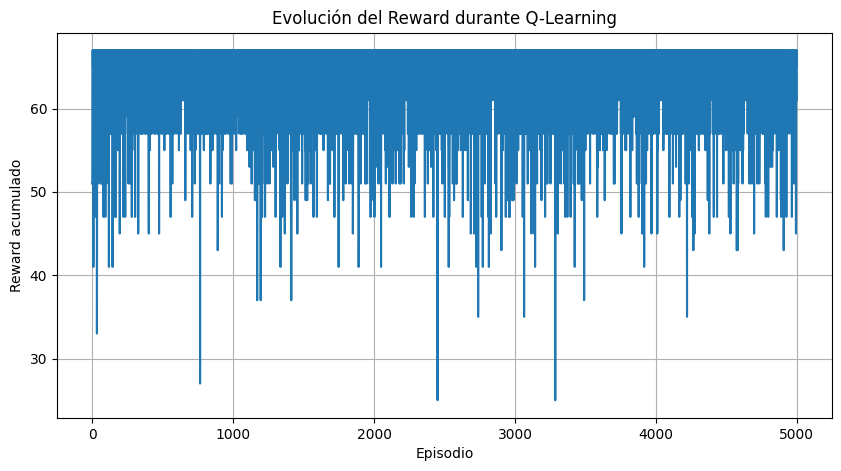


RESULTADO DEL AGENTE
Ruta encontrada:
(0, 0)
(1, 0)
(2, 0)
(3, 0)
(3, 1)
(4, 1)
(4, 2)
(4, 3)
(4, 4)
(5, 4)
(6, 4)
(7, 4)
(7, 5)

Reward total: 67
Número de pasos: 12

MAPA + RUTA
S . . L . . . .
* # . L . # # .
* # . . . . . .
* * # # # L # .
# * * * * . # .
. # # # * . L .
. . . # * # # .
. . . . * * T .


In [69]:
rewards_2 = {
    "move": -3, # Disminuimos mas la recompensa de movimiento
    "wait": -2,
    "obstacle": -10,
    "red_light": -10,
    "destination": 100
}

# Creamos un nuevo ambienrte con las nuevas recompensas
environment = CityEnvironment(rewards_2)

# Entrenar el módelo
train_agent(episodes, environment, epsilon)

# Probamos el nuevo agente
path = test_agent(episodes, environment)

# Graficamos la ruta

graph_path(path)


### 🧠 Interpretación

Al penalizar más cada paso, el agente aprendió efectivamente a optimizar su trayectoria hasta alcanzar la meta (`T`) desde el punto de inicio (`S`) en un total de solo 12 pasos, obteniendo una recompensa total de 67; sin embargo, la gráfica de *Reward acumulado* muestra fluctuaciones constantes y caídas marcadas hacia valores más bajos a lo largo de los 5000 episodios, lo que indica que el proceso de exploración continuó afectando el desempeño paso a paso antes de estabilizar la política óptima.

##  📈 Experimento 2: hacer que esperar sea más costoso

En este segundo experimento vamos a cambiar la lista de recompensas en la espera del semaforo para que sea mas costoso y tambien los obstaculos.

Episodio 500 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 1000 | Reward: 85 | Steps: 16 | Epsilon: 0.050
Episodio 1500 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 2000 | Reward: 79 | Steps: 13 | Epsilon: 0.050
Episodio 2500 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 3000 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 3500 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 4000 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 4500 | Reward: 79 | Steps: 13 | Epsilon: 0.050
Episodio 5000 | Reward: 89 | Steps: 12 | Epsilon: 0.050

Entrenamiento terminado.
Epsilon final: 0.05
Mejor reward: 89


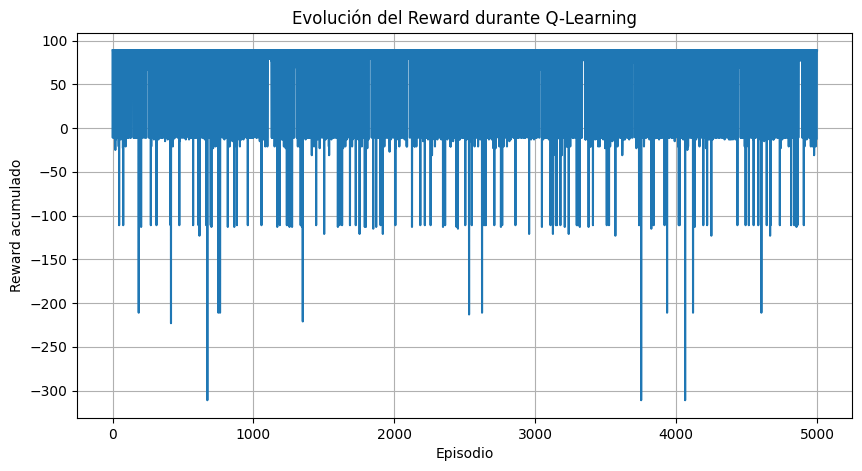


RESULTADO DEL AGENTE
Ruta encontrada:
(0, 0)
(1, 0)
(2, 0)
(3, 0)
(3, 1)
(4, 1)
(4, 2)
(4, 3)
(4, 4)
(5, 4)
(6, 4)
(7, 4)
(7, 5)

Reward total: 89
Número de pasos: 12

MAPA + RUTA
S . . L . . . .
* # . L . # # .
* # . . . . . .
* * # # # L # .
# * * * * . # .
. # # # * . L .
. . . # * # # .
. . . . * * T .


In [70]:
rewards_3 = {
    "move": -1,
    "wait": -10, # Disminuimos mas para que sea mas costoso
    "obstacle": -100,  # Disminuimos mas para que sea mas costoso
    "red_light": -50, # Disminuimos mas para que sea mas costoso
    "destination": 100
}

# Creamos un nuevo ambienrte con las nuevas recompensas
environment = CityEnvironment(rewards_3)

# Entrenar el módelo
train_agent(episodes, environment, epsilon)

# Probamos el nuevo agente
path = test_agent(episodes, environment)

# Graficamos la ruta

graph_path(path)


### 🧠 Interpretación de Gráfico

Al aumentar el costo de la espera en semáforos y las penalizaciones por obstáculos, el agente logró mantener un trayecto óptimo de 12 pasos pero obtuvo un *Reward total* más alto (89 frente a 67 del primer experimento), lo que demuestra que aprendió exitosamente a esquivar los semáforos (`L`) y obstáculos (`#`) para maximizar su recompensa; no obstante, la gráfica revela caídas mucho más severas en el *Reward acumulado* (llegando a valores inferiores a -300), lo cual refleja el alto costo punitivo que sufrió el agente durante las fases de exploración cuando cometía errores al tropezar con obstáculos o esperar innecesariamente.

##  📈 Experimento 3: aumentar la tasa de aprendizaje

Intentamos analiza que α determina cuánto influye una nueva experiencia sobre el valor Q existente. Con 0.5, las nuevas experiencias tienen una influencia mayor, por lo que el agente puede aprender más rápidamente, aunque los valores Q pueden cambiar más bruscamente durante el entrenamiento.

Episodio 500 | Reward: 87 | Steps: 13 | Epsilon: 0.082
Episodio 1000 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 1500 | Reward: 79 | Steps: 13 | Epsilon: 0.050
Episodio 2000 | Reward: 87 | Steps: 13 | Epsilon: 0.050
Episodio 2500 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 3000 | Reward: 85 | Steps: 16 | Epsilon: 0.050
Episodio 3500 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 4000 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 4500 | Reward: 85 | Steps: 15 | Epsilon: 0.050
Episodio 5000 | Reward: 89 | Steps: 12 | Epsilon: 0.050

Entrenamiento terminado.
Epsilon final: 0.05
Mejor reward: 89


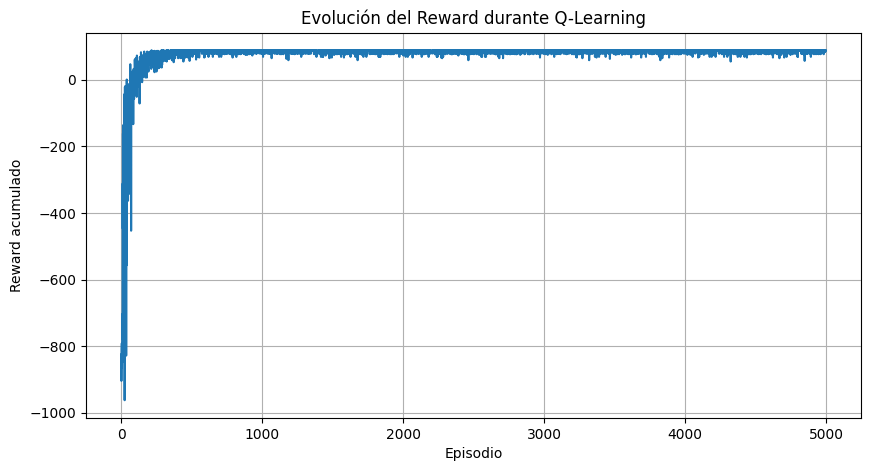


RESULTADO DEL AGENTE
Ruta encontrada:
(0, 0)
(1, 0)
(2, 0)
(3, 0)
(3, 1)
(4, 1)
(4, 2)
(4, 3)
(4, 4)
(5, 4)
(6, 4)
(7, 4)
(7, 5)

Reward total: 89
Número de pasos: 12

MAPA + RUTA
S . . L . . . .
* # . L . # # .
* # . . . . . .
* * # # # L # .
# * * * * . # .
. # # # * . L .
. . . # * # # .
. . . . * * T .


In [71]:
# Ajustes de nuevo alpha para el aprendizaje
alpha = 0.5
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

# Creamos un nuevo ambienrte con las recompensas original
environment = CityEnvironment(rewards)

# Entrenar el módelo
train_agent(episodes, environment, epsilon)

# Probamos el nuevo agente
path = test_agent(episodes, environment)

# Graficamos la ruta

graph_path(path)

### 🧠 Interpretación de Gráfico

Al aumentar la tasa de aprendizaje ($\alpha = 0.5$), el agente aceleró drásticamente su convergencia, logrando estabilizar la curva de *Reward acumulado* cerca del valor óptimo en muy pocos episodios iniciales y manteniendo una trayectoria perfecta de 12 pasos con una recompensa total de 89; a diferencia de los experimentos anteriores, la gráfica muestra cómo, tras una caída fuerte en la exploración inicial (llegando a casi -1000), las oscilaciones desaparecen casi por completo a medida que avanzan los episodios, lo que confirma que el modelo actualiza y fija los valores Q de manera mucho más rápida y sólida ante las nuevas experiencias.

##  📈 Experimento 4: disminuir γ

Estamos analizando γ controla cuánto considera el agente las recompensas futuras. Con 0.5, las recompensas futuras tienen menos peso que con 0.95, por lo que el agente se concentra más en las consecuencias inmediatas de sus acciones.

Episodio 500 | Reward: 79 | Steps: 13 | Epsilon: 0.082
Episodio 1000 | Reward: 87 | Steps: 14 | Epsilon: 0.050
Episodio 1500 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 2000 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 2500 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 3000 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 3500 | Reward: 77 | Steps: 15 | Epsilon: 0.050
Episodio 4000 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 4500 | Reward: 89 | Steps: 12 | Epsilon: 0.050
Episodio 5000 | Reward: 79 | Steps: 13 | Epsilon: 0.050

Entrenamiento terminado.
Epsilon final: 0.05
Mejor reward: 89


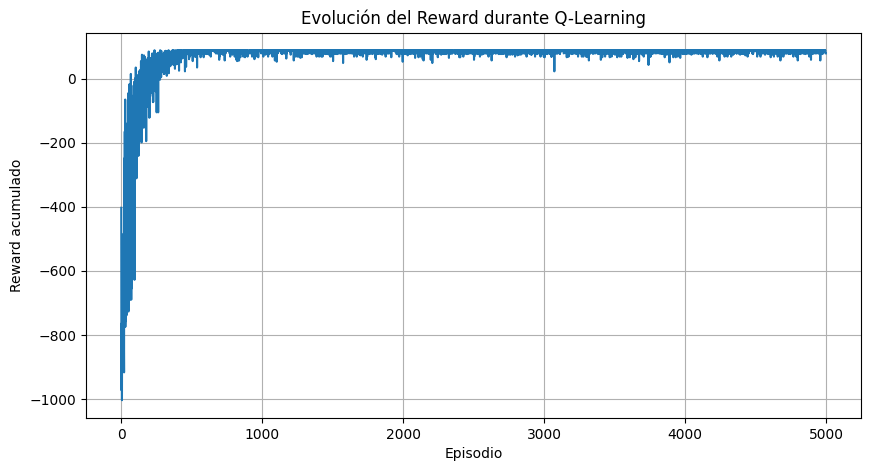


RESULTADO DEL AGENTE
Ruta encontrada:
(0, 0)
(1, 0)
(2, 0)
(3, 0)
(3, 1)
(4, 1)
(4, 2)
(4, 3)
(4, 4)
(5, 4)
(6, 4)
(7, 4)
(7, 5)

Reward total: 89
Número de pasos: 12

MAPA + RUTA
S . . L . . . .
* # . L . # # .
* # . . . . . .
* * # # # L # .
# * * * * . # .
. # # # * . L .
. . . # * # # .
. . . . * * T .


In [72]:
# Ajustes de nuevo alpha para el aprendizaje
alpha = 0.1
gamma = 0.5 # Aumentamos gamma para que considere la recompensa
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

# Creamos un nuevo ambienrte con las recompensas original
environment = CityEnvironment(rewards)

# Entrenar el módelo
train_agent(episodes, environment, epsilon)

# Probamos el nuevo agente
path = test_agent(episodes, environment)

# Graficamos la ruta

graph_path(path)

### 🧠 Interpretación de Gráfico

Al disminuir el factor de descuento ($\gamma = 0.5$), el agente prioriza las recompensas inmediatas y aun así logra converger exitosamente hacia la ruta óptima de 12 pasos con una recompensa total de 89; no obstante, la gráfica muestra que la curva de aprendizaje tarda un poco más en estabilizarse durante los primeros episodios en comparación con el experimento previo (presentando una variabilidad inicial más densa con caídas cercanas a -1000), lo cual refleja que, al darle menos peso al beneficio futuro a largo plazo, al agente le cuesta un poco más de exploración conectar las decisiones locales con la recompensa final de la meta.

# 🤔 Hallazgos y conclusiones

## 🚀 ¿Qué podemos concluir en base al analisis realizado?


## ⭐ Preguntas reflexivas

### 1. **¿Cómo influyó el ajuste de la función de recompensas y penalizaciones en el comportamiento del agente?**

Al incrementar las penalizaciones por movimiento, espera en semáforos y colisión con obstáculos, el agente aprendió a evitar pasos innecesarios e interacciones riesgosas, logrando incrementar su recompensa total de 67 a 89 sin perder la ruta óptima de 12 pasos. Sin embargo, esto provocó caídas mucho más severas en el reward acumulado durante las fases de exploración debido al alto costo de errar.

### **¿Qué impacto tuvo el incremento de la tasa de aprendizaje ($\alpha = 0.5$) en la convergencia del modelo?**

El aumento de $\alpha$ permitió que las nuevas experiencias tuvieran un peso mayor e inmediato sobre la matriz Q, logrando acelerar drásticamente la convergencia del agente. Esto redujo casi por completo la oscilación del reward acumulado tras los episodios iniciales de exploración y estabilizó la política óptima con mayor rapidez en comparación con los experimentos anteriores

### 3. **¿De qué manera afectó la reducción del factor de descuento ($\gamma = 0.5$) a la toma de decisiones a largo plazo?**

Al reducir $\gamma$, el agente pasó a priorizar el beneficio inmediato sobre las recompensas futuras, lo que ocasionó que la curva de aprendizaje tardara un poco más en estabilizarse en los episodios iniciales. A pesar de esta miopía temporal en la exploración temprana, el agente logró mantener la estrategia óptima de 12 pasos y alcanzar el máximo reward de 89.

### 4. **¿Cuál es la ruta más corta entre los 4 experimentos?**

En los 4 experimentos la distancia de la ruta más corta fue exactamente la misma: 12 pasos.   En todas las pruebas, el agente encontró exactamente la misma trayectoria óptima de 12 coordenadas para ir desde el punto de origen $(0,0)$ hasta la meta $(7,5)$:   Ruta: (0,0) → (1,0) → (2,0) → (3,0) → (3,1) → (4,1) → (4,2) → (4,3) → (4,4) → (5,4) → (6,4) → (7,4) → (7,5)   La diferencia principal entre los experimentos no estuvo en la longitud de la ruta (que se mantuvo constante en 12 pasos), sino en la rapidez con la que el agente aprendió a encontrarla (mayor velocidad de convergencia en el Experimento 3 con $\alpha = 0.5$) y en el puntaje total obtenido (pasando de 67 de reward en el Exp. 1 a 89 de reward en los Exp. 2, 3 y 4 al aprender a esquivar mejor los semáforos y obstáculos).  Recordemos que el experimento 4 son las mismas recompensas, por lo tanto tenemos que la ruta inicial es la menor.

### 5. **Es la ruta aprendida realmente la más corta?**

Sí, es geométrica y topológicamente la ruta más corta posible. En una cuadrícula bidimensional de $8 \times 8$ (con filas de $0$ a $7$ y columnas de $0$ a $7$), la distancia Manhattan entre el inicio $(0,0)$ y la meta $(7,5)$ es de $12$ pasos:


$$\text{Distancia} = \vert{}7 - 0\vert{} + \vert{}5 - 0\vert{} = 7 + 5 = 12$$

Dado que el agente únicamente se desplaza en direcciones ortogonales (arriba, abajo, izquierda, derecha) sin movimientos diagonales, es imposible llegar a la meta en menos de $12$ movimientos. Por lo tanto, el agente encontró la ruta globalmente óptima en longitud.2. Factores que hacen que una ruta sea más conveniente que otra en Aprendizaje por Refuerzo:Longitud o número de pasos (Distancia Manhattan): A menor número de transiciones, menor es la penalización acumulada por movimiento. Una ruta más corta minimiza el costo temporal y espacial para llegar al objetivo.Costos del entorno y penalizaciones (Obstáculos y Semáforos): No basta con que una ruta sea corta; debe ser segura y barata. Atravesar obstáculos (#) o esperar en semáforos (L) genera penalizaciones negativas severas. Una ruta conveniente rodea estas amenazas sin añadir pasos innecesarios.Acumulación de Recompensa Neta ($Q$-Value / Reward): En el algoritmo de $Q$-Learning, la conveniencia de una ruta está determinada por la maximización del retorno esperado. La mejor ruta es aquella que balancea la distancia mínima con la menor cantidad de penalizaciones, logrando la recompensa total más alta (89 puntos en los experimentos con mejores penalizaciones).   

In [73]:
# Asegúrate de que nbconvert esté instalado
!pip install nbconvert

In [76]:
# 1. Define la URL del notebook en GitHub
github_notebook_url = 'https://raw.githubusercontent.com/ChrisJavier/UIDE_3-WorkGroupModelsKind/refs/heads/main/Week03/src/KM_CP_W3_E3.ipynb'
local_notebook_filename = 'KM_CP_W3_E3.ipynb'
html_output_filename_github = 'KM_CP_W3_E3.html'

# 2. Descarga el notebook desde GitHub
!wget -O "{local_notebook_filename}" "{github_notebook_url}"
print(f"Notebook '{local_notebook_filename}' descargado desde GitHub.")

# 3. Convierte el notebook descargado a HTML
!jupyter nbconvert --to html "{local_notebook_filename}" --output "{html_output_filename_github}"
print(f"Conversión a HTML completada. Archivo '{html_output_filename_github}' generado.")

--2026-09-21 13:55:31--  https://raw.githubusercontent.com/ChrisJavier/UIDE_3-WorkGroupModelsKind/refs/heads/main/Week03/src/KM_CP_W3_E3.ipynb
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 290985 (284K) [text/plain]
Saving to: ‘KM_CP_W3_E3.ipynb’

KM_CP_W3_E3.ipynb   100%[===================>] 284.17K  --.-KB/s    in 0.03s   

2026-09-21 13:55:32 (10.2 MB/s) - ‘KM_CP_W3_E3.ipynb’ saved [290985/290985]

Notebook 'KM_CP_W3_E3.ipynb' descargado desde GitHub.
[NbConvertApp] Converting notebook KM_CP_W3_E3.ipynb to html
/usr/local/lib/python3.13/dist-packages/nbformat/validator.py:434: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validati

In [77]:
# 4. Ofrece el archivo HTML para descargar
from google.colab import files
files.download('KM_CP_W3_E3.html')

print("El archivo HTML descargado de GitHub debería aparecer en tu navegador.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

El archivo HTML descargado de GitHub debería aparecer en tu navegador.
